# ColonySearch — Hyperparameter Tuning Benchmark

Compares **PSO**, **QPSO**, **Grid Search**, and **Random Search** on local node search quality.
All nodes in `data/dbs/` are used together so the optimiser sees every topic cluster.

Metric: **NDCG@10** — ground truth = documents sharing the same topic label on the same node.

In [7]:
import sys
from pathlib import Path

# Walk up from CWD until we find the project root (works wherever Jupyter is launched)
_ROOT = Path().resolve()
for _ in range(6):
    if (_ROOT / 'data' / 'dbs').exists():
        break
    _ROOT = _ROOT.parent
sys.path.insert(0, str(_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from data.tuning.ground_truth import load_all_ground_truth
from data.tuning.metrics import evaluate
from data.tuning.algos import BOUNDS
from data.tuning.algos.pso import PSO
from data.tuning.algos.qpso import QPSO
from data.tuning.algos.grid_search import GridSearch
from data.tuning.algos.random_search import RandomSearch

DATA_DIR = _ROOT / 'data'
K = 10
print(f'Project root: {_ROOT}')

Project root: /home/lukas/Documents/Uni/THN/IntroBC/ColonySearch


## Parameter Bounds

These are the search ranges for all three algorithms.  
Edit this cell to explore different parts of the space.

In [8]:
# BOUNDS is imported from algos/__init__.py — one source of truth.
# Format: [(min, max), ...] for [link_bias, svd_dims, alpha]
print('Parameter bounds:')
labels = ['link_bias  (link-graph weight vs text embeddings)', 'svd_dims   (link-graph SVD dimensions, rounded to int)', 'alpha      (BM25 weight in final score; 1-alpha = KNN weight)']
for (lo, hi), label in zip(BOUNDS, labels):
    print(f'  {label}')
    print(f'      range: [{lo}, {hi}]')

# You can override bounds for a specific algo by passing them explicitly:
#   QPSO(bounds=[(0.0, 1.0), (8, 64), (0.0, 1.0)])  <- narrower search
print()
print('Current BOUNDS:', BOUNDS)

Parameter bounds:
  link_bias  (link-graph weight vs text embeddings)
      range: [0.0, 2.0]
  svd_dims   (link-graph SVD dimensions, rounded to int)
      range: [8, 128]
  alpha      (BM25 weight in final score; 1-alpha = KNN weight)
      range: [0.0, 1.0]

Current BOUNDS: [(0.0, 2.0), (8, 128), (0.0, 1.0)]


In [9]:
from data.tuning.ground_truth import extract_topics, generate_topic_queries, load_shared_ground_truth

print('Loading ground truth across all nodes ...')

USE_SHARED_QUERIES = True
if USE_SHARED_QUERIES:
    topics = extract_topics(DATA_DIR)
    queries = generate_topic_queries(topics, n_per_topic=2, style='mixed')
    test_cases = load_shared_ground_truth(DATA_DIR, queries)
else:
    test_cases = load_all_ground_truth(DATA_DIR)

unique_clusters = len({frozenset(tc['relevant_urls']) for tc in test_cases})
print(f'\nTotal: {len(test_cases)} test queries across {unique_clusters} topic clusters')

# Show test queries; set NODE_FILTER to [] for all nodes
NODE_FILTER = []  # e.g. ['Node_1', 'Node_3']
cases_to_show = [tc for tc in test_cases if not NODE_FILTER or tc['node_dir'].name in NODE_FILTER]
print('\nTest queries (preview):')
for tc in cases_to_show[:50]:
    print(f"- [{tc['node_dir'].name}] {tc['query_text'][:120]}...")

if USE_SHARED_QUERIES:
    print('\nShared queries (preview):')
    for q in queries[:50]:
        print(f"- {q['query_text']}")

Loading ground truth across all nodes ...
  Node_1: 22 shared test cases
  Node_2: 22 shared test cases
  Node_3: 22 shared test cases

Total: 66 test queries across 25 topic clusters

Test queries (preview):
- [Node_1] climate_change...
- [Node_1] why climate_change matters...
- [Node_1] economics guide...
- [Node_1] economics examples...
- [Node_1] how to use football...
- [Node_1] football...
- [Node_1] medicine...
- [Node_1] what is medicine...
- [Node_1] how to use ml_algorithms...
- [Node_1] why ml_algorithms matters...
- [Node_1] what is neuroscience...
- [Node_1] why neuroscience matters...
- [Node_1] why programming matters...
- [Node_1] programming examples...
- [Node_1] quantum_computing guide...
- [Node_1] quantum_computing overview...
- [Node_1] how to use smart_manufacturing...
- [Node_1] why smart_manufacturing matters...
- [Node_1] what is space...
- [Node_1] why space matters...
- [Node_1] sustainable_materials basics...
- [Node_1] sustainable_materials examples...
- [

## Algorithm Configuration

For a **quick test** run, use the commented-out small-budget versions below.

In [10]:
def make_objective(test_cases, k):
    def objective(params):
        return -evaluate(params, test_cases, k=k)['mean_ndcg']
    return objective

objective_fn = make_objective(test_cases, K)

# ── Full budget (comment out for quick test) ──────────────────────────────
algos = [
    ('PSO',    PSO(n_particles=30, max_iter=20)),
    ('QPSO',   QPSO(n_particles=30, max_iter=20)),
    ('Grid',   GridSearch(n_per_dim=5)),
    ('Random', RandomSearch(n_evaluations=200)),
]

# ── Quick test (~50 evals total, a few minutes) ───────────────────────────
# algos = [
#     ('PSO',    PSO(n_particles=5, max_iter=4)),
#     ('QPSO',   QPSO(n_particles=5, max_iter=4)),
#     ('Grid',   GridSearch(n_per_dim=3)),
#     ('Random', RandomSearch(n_evaluations=27)),
# ]

import time
results = {}
for name, algo in algos:
    t0 = time.time()
    print(f'Running {name} ...')
    results[name] = algo.optimize(objective_fn)
    elapsed = time.time() - t0
    print(f'  Best NDCG@{K}: {-results[name].best_fitness:.4f}  ({results[name].n_evals} evals, {elapsed:.0f}s)')

print('\nDone.')

Running PSO ...
  Best NDCG@10: 0.9707  (600 evals, 1242s)
Running QPSO ...
  Best NDCG@10: 0.9748  (600 evals, 1523s)
Running Grid ...
  Best NDCG@10: 0.9699  (125 evals, 301s)
Running Random ...
  Best NDCG@10: 0.9745  (200 evals, 454s)

Done.


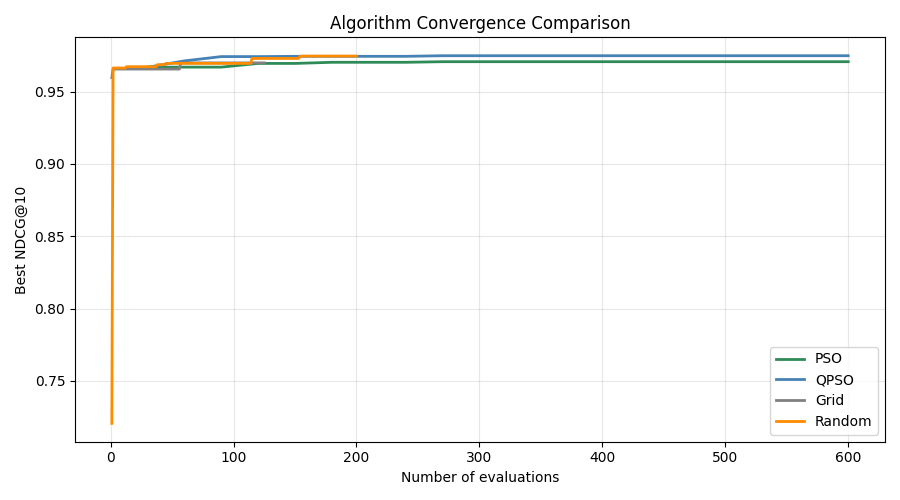

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = {'PSO': 'seagreen', 'QPSO': 'steelblue', 'Grid': 'gray', 'Random': 'darkorange'}
for name, res in results.items():
    xs = [h['n_evals']   for h in res.history]
    ys = [h['best_ndcg'] for h in res.history]
    ax.plot(xs, ys, label=name, color=colors[name], linewidth=2)

ax.set_xlabel('Number of evaluations')
ax.set_ylabel('Best NDCG@10')
ax.set_title('Algorithm Convergence Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('benchmark_convergence.png', dpi=120)
plt.show()

In [12]:
rows = []
for name, res in results.items():
    lb, svd, alpha = res.best_params
    metrics = evaluate(res.best_params, test_cases, k=K)
    rows.append({
        'Algorithm':         name,
        'Best NDCG@10':      round(metrics['mean_ndcg'], 4),
        'Best Precision@10': round(metrics['mean_precision'], 4),
        'Best Recall@10':    round(metrics['mean_recall'], 4),
        'Total Evals':       res.n_evals,
        'Best Params':       f'lb={lb:.2f}, svd={int(round(svd))}, a={alpha:.2f}',
    })

df = pd.DataFrame(rows).set_index('Algorithm')
display(df.style.highlight_max(subset=['Best NDCG@10', 'Best Precision@10', 'Best Recall@10']))

,Best NDCG@10,Best Precision@10,Best Recall@10,Total Evals,Best Params
Algorithm,,,,,
PSO,0.970700,0.831200,0.354900,600,"lb=0.00, svd=8, a=0.40"
QPSO,0.974800,0.835400,0.355700,600,"lb=0.50, svd=61, a=0.37"
Grid,0.969900,0.829200,0.354000,125,"lb=0.50, svd=22, a=0.25"
Random,0.974500,0.835400,0.355700,200,"lb=0.48, svd=61, a=0.38"


## Grid Search Heatmap

NDCG@10 across `alpha × link_bias` with `svd_dims` fixed at the best value found.

Sweeping alpha x link_bias (svd_dims=22) ...


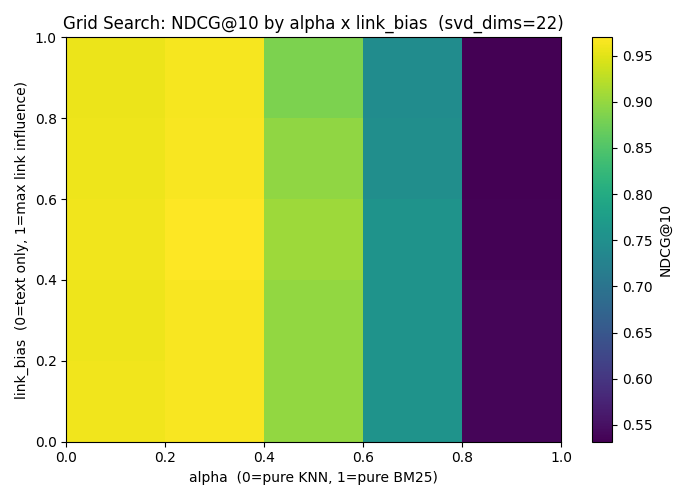

In [13]:
grid_res = results['Grid']
best_lb, best_svd, best_alpha = grid_res.best_params
best_svd_int = int(round(best_svd))

n = 5
lb_vals    = np.linspace(0.0, 1.0, n)
alpha_vals = np.linspace(0.0, 1.0, n)

print(f'Sweeping alpha x link_bias (svd_dims={best_svd_int}) ...')
ndcg_grid = np.zeros((n, n))
for i, lb in enumerate(lb_vals):
    for j, al in enumerate(alpha_vals):
        m = evaluate([lb, best_svd_int, al], test_cases, k=K)
        ndcg_grid[i, j] = m['mean_ndcg']

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(ndcg_grid, origin='lower', aspect='auto',
               extent=[0, 1, 0, 1], cmap='viridis')
fig.colorbar(im, ax=ax, label='NDCG@10')
ax.set_xlabel('alpha  (0=pure KNN, 1=pure BM25)')
ax.set_ylabel('link_bias  (0=text only, 1=max link influence)')
ax.set_title(f'Grid Search: NDCG@10 by alpha x link_bias  (svd_dims={best_svd_int})')
fig.tight_layout()
plt.show()

## QPSO Particle Trace

Each point is one evaluated position in the `link_bias × alpha` plane (svd_dims collapsed).
Colour = NDCG@10 at that point; red star = global best.

Running QPSO trace (separate run for visualisation) ...


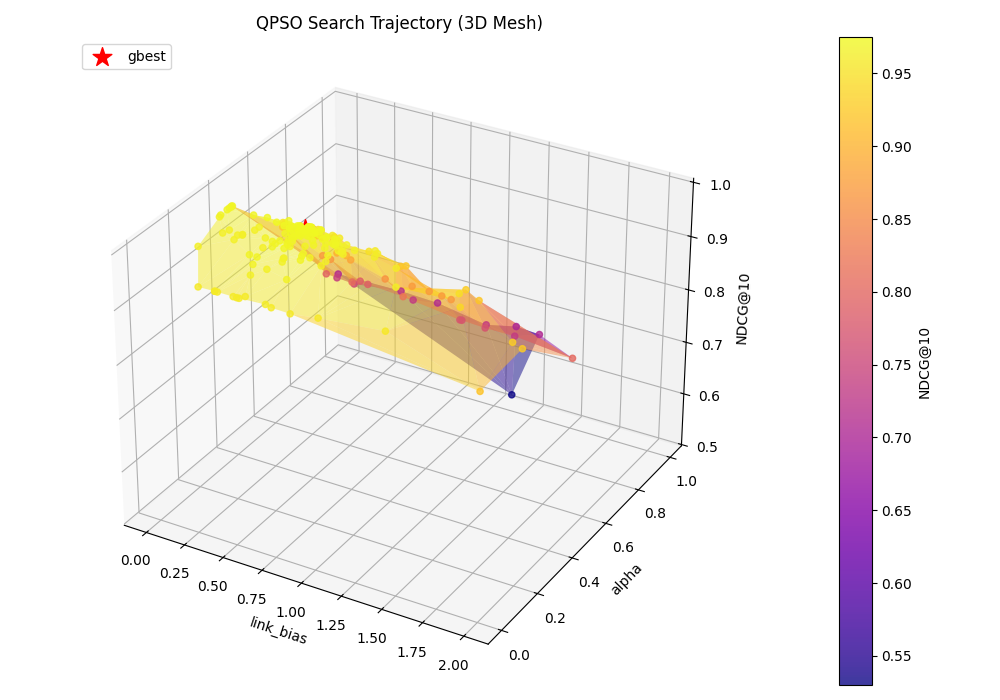

QPSO trace best: NDCG=0.9748  params=[0.502, 104.454, 0.374]


In [14]:
%matplotlib widget

positions = []

def recording_objective(params):
    m = evaluate(params, test_cases, k=K)
    positions.append((float(params[0]), float(params[2]), m['mean_ndcg']))
    return -m['mean_ndcg']

print('Running QPSO trace (separate run for visualisation) ...')
qpso_trace = QPSO(n_particles=20, max_iter=10, seed=99)
trace_res = qpso_trace.optimize(recording_objective)

lbs, alphas, ndcgs = zip(*positions)
best_lb, _, best_alpha = trace_res.best_params
best_ndcg = -trace_res.best_fitness

import matplotlib.tri as mtri
tri = mtri.Triangulation(lbs, alphas)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(tri, ndcgs, cmap='plasma', alpha=0.5, linewidth=0.2)
sc = ax.scatter(lbs, alphas, ndcgs, c=ndcgs, cmap='plasma', s=20, alpha=0.8)
fig.colorbar(sc, ax=ax, pad=0.12, label='NDCG@10')
ax.scatter([best_lb], [best_alpha], [best_ndcg], marker='*', s=200, color='red', zorder=5, label='gbest')
ax.set_xlabel('link_bias')
ax.set_ylabel('alpha')
ax.set_zlabel('NDCG@10')
ax.set_title('QPSO Search Trajectory (3D Mesh)')
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()
print(f'QPSO trace best: NDCG={best_ndcg:.4f}  params={[round(x,3) for x in trace_res.best_params]}')

Running PSO trace (separate run for visualisation) ...


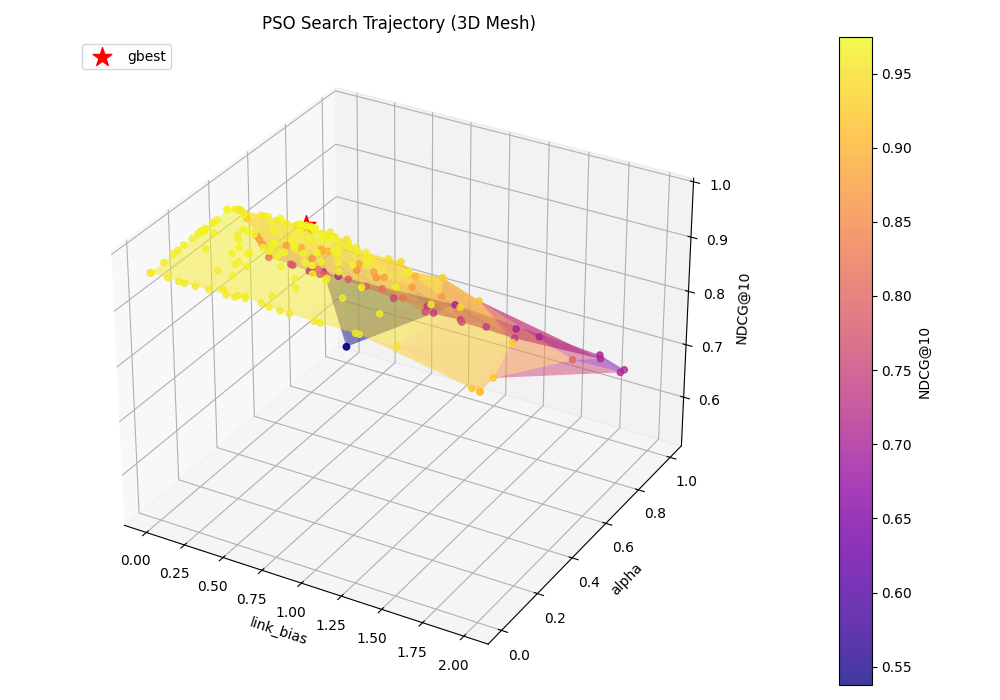

PSO trace best: NDCG=0.9744  params=[0.485, 128.0, 0.395]


In [16]:
%matplotlib widget

pso_positions = []

def pso_recording_objective(params):
    m = evaluate(params, test_cases, k=K)
    pso_positions.append((float(params[0]), float(params[2]), m['mean_ndcg']))
    return -m['mean_ndcg']

print('Running PSO trace (separate run for visualisation) ...')
pso_trace = PSO(n_particles=20, max_iter=10, seed=99)
pso_trace_res = pso_trace.optimize(pso_recording_objective)

lbs, alphas, ndcgs = zip(*pso_positions)
best_lb, _, best_alpha = pso_trace_res.best_params
best_ndcg = -pso_trace_res.best_fitness

import matplotlib.tri as mtri
tri = mtri.Triangulation(lbs, alphas)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(tri, ndcgs, cmap='plasma', alpha=0.5, linewidth=0.2)
sc = ax.scatter(lbs, alphas, ndcgs, c=ndcgs, cmap='plasma', s=20, alpha=0.8)
fig.colorbar(sc, ax=ax, pad=0.12, label='NDCG@10')
ax.scatter([best_lb], [best_alpha], [best_ndcg], marker='*', s=200, color='red', zorder=5, label='gbest')
ax.set_xlabel('link_bias')
ax.set_ylabel('alpha')
ax.set_zlabel('NDCG@10')
ax.set_title('PSO Search Trajectory (3D Mesh)')
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()
print(f'PSO trace best: NDCG={best_ndcg:.4f}  params={[round(x,3) for x in pso_trace_res.best_params]}')